In [228]:
import numpy as np
import pandas as pd
import tensorflow as tf
import requests
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV 
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
import os
import warnings

# Step 1. Calling API

## API Function for Dwelling dataset and business dataset

In [2]:
def fetch_data(base_url, dataset, api_key, num_records, max_offset,where, offset):
    all_records =[]
    #Maximum number of requests

    while True:
        # Maximum limit check
        if offset > max_offset:
            break
        
        # Create API request URL
        
        filters = f'{dataset}/records?&limit={num_records}&offset={offset}&where={where}'
        url = f'{base_url}{filters}&api_key={api_key}'

        try:
            result = requests.get(url, timeout=10)
            result.raise_for_status()
            records = result.json().get('results')
        except requests.exceptions.RequestException as e:
            raise Exception(f'API request failed: {e}')
        
        if records is None:
            break
        
        all_records.extend(records)
        if len(records) < num_records:
            break
        
        # next cycle offset
        offset += num_records
    
    # Dataframe all data
    df = pd.DataFrame(all_records)
    return df

## Creating the DataSet .
#### - API key is obtained from the MOP wensite.
#### - API for dataset is displayed below:
https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/development-activity-monitor/records?limit=20<br>
https://data.melbourne.vic.gov.au/explore/dataset/cafes-and-restaurants-with-seating-capacity/api/?refine.census_year=2022<br>
https://data.melbourne.vic.gov.au/explore/dataset/employment-by-block-by-clue-industry/api/<br>
https://data.melbourne.vic.gov.au/explore/dataset/employment-by-block-by-clue-industry/api/

In [3]:
# PERSONLA KEY: eb67c6d708fd15de910be7c7a1e7c7eac64c7c0ad1da6c6f7a8fe928
API_KEY = 'c3fe52b3c0f0f3a2d07fc8d89192f5bd3e3234c68b2c30adcd8ab5ca'
BASE_URL = "https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/"
DATASET_DEVELOPMENT = 'development-activity-monitor'
DATASET_BUS = 'business-establishments-per-block-by-anzsic'
NUM_RECORD = 100
MAX_OFFSET_DEV = 1420
MAX_OFFSET_BUS = 12394
OFFSET = 0
# General select and group_by for Business and Dwelling
WHERE_DEV = ''
WHERE_BUS_2011 = 'census_year%20%3E%202010'
WHERE_BUS_2010 ='census_year%20%3C%202011'

In [127]:
# Dwelling dataset
df_dev = fetch_data(BASE_URL, DATASET_DEVELOPMENT, API_KEY, NUM_RECORD, MAX_OFFSET_DEV, WHERE_DEV, OFFSET)
df_dev.shape

(1430, 42)

In [7]:
# Breakdown Business dataset into two due to size
df_2011 = fetch_data(BASE_URL, DATASET_BUS, API_KEY, NUM_RECORD, MAX_OFFSET_BUS, WHERE_BUS_2011, OFFSET)

In [8]:
df_2011.shape

(7279, 23)

In [9]:
df_2010 = fetch_data(BASE_URL, DATASET_BUS, API_KEY, NUM_RECORD, MAX_OFFSET_BUS,WHERE_BUS_2010, OFFSET)
df_2010.shape

(5115, 23)

In [10]:
# Merging the business datasets together
df_bus = pd.concat([df_2011,df_2010])
df_bus.shape

(12394, 23)

## Due to the cafe dataset size - aggregate was used to reduce the size of the dataset

In [11]:
def fetch_data_cafe(base_url, api_key,offset,max_offset,num_records):
    all_records =[]
    #Maximum number of requests

    while True:
        # Maximum limit check
        if offset > max_offset:
            break
        
        # Create API request URL
        
        url = f'{base_url}&api_key={api_key}'

        try:
            result = requests.get(url, timeout=10)
            result.raise_for_status()
            records = result.json().get('results')
        except requests.exceptions.RequestException as e:
            raise Exception(f'API request failed: {e}')
        
        if records is None:
            break
        
        all_records.extend(records)
        if len(records) < num_records:
            break
        
        # next cycle offset
        offset += num_records
    
    # Dataframe all data
    df = pd.DataFrame(all_records)
    return df

In [12]:
URL_C = 'https://data.melbourne.vic.gov.au/api/explore/v2.1/catalog/datasets/cafes-and-restaurants-with-seating-capacity/records?select=census_year%2C%20clue_small_area%2C%20count(industry_anzsic4_code)%20as%20total&group_by=census_year%2C%20clue_small_area'
API_KEY_C = 'c3fe52b3c0f0f3a2d07fc8d89192f5bd3e3234c68b2c30adcd8ab5ca'
OFFSET_C = 0
MAX_OFFSET_CAF = 10000
NUM_RECORD_C = 100

In [108]:
dfc = fetch_data_cafe(URL_C, API_KEY_C, OFFSET_C,MAX_OFFSET_CAF,NUM_RECORD_C )
dfc.shape

(27573, 3)

# Step 2. Checking the quality of the data

## Dwelling dataset
## Need to clean up dataset
The aim of this data set is to extract the number of dwelling in individual clue_small_area for each year.
1. Use data with Status = COMPLETED - To avoild duplicates.
2. Identify required fields 
3. Produce the total Number of residential dwelling for individual clue_small_ares for each year.
4. Identify the new dataset field types and adjust.
5. Check data for missing values

In [128]:
df_dev2= df_dev.copy()

In [129]:
df_dev.head(2)

,data_format,development_key,status,year_completed,clue_small_area,clue_block,street_address,property_id,property_id_2,property_id_3,...,hospital_flr,recreation_flr,publicdispaly_flr,community_flr,car_spaces,bike_spaces,town_planning_application,longitude,latitude,geopoint
0,Pre May 16,X000479,COMPLETED,2006,North Melbourne,342,191-201 Abbotsford Street NORTH MELBOURNE VIC ...,100023,None,None,...,0,0,0,0,0,0,0,144.945030,-37.802822,"{'lon': 144.9450298, 'lat': -37.80282184}"
1,Pre May 16,X000459,COMPLETED,2005,North Melbourne,333,218-224 Abbotsford Street NORTH MELBOURNE VIC ...,100119,None,None,...,0,0,0,0,0,0,0,144.945947,-37.802049,"{'lon': 144.9459475, 'lat': -37.80204879}"


In [130]:
#1. Use data with Status = COMPLETED
df_dev = df_dev.loc[df_dev['status'] == 'COMPLETED']

In [132]:
#2. Identify required fields
df_dev.iloc[:,[3,4,13,14,15,16,17,18]].head(10)

,year_completed,clue_small_area,resi_dwellings,studio_dwe,one_bdrm_dwe,two_bdrm_dwe,three_bdrm_dwe,student_apartments
0,2006,North Melbourne,17,0,0,0,0,0
1,2005,North Melbourne,12,0,0,0,0,0
2,2013,West Melbourne (Residential),3,0,0,0,3,0
3,2014,West Melbourne (Residential),28,0,17,11,0,0
4,2007,North Melbourne,0,0,0,0,0,0
5,2002,Carlton,14,0,0,0,0,0
6,2015,Melbourne (Remainder),0,0,0,0,0,0
7,2009,West Melbourne (Residential),0,0,0,0,0,0
8,2010,Melbourne (CBD),0,0,0,0,0,0
9,2006,Carlton,0,0,0,0,0,70


In [133]:
#3. Produce the total Number of residential dwelling for individual clue_small_ares for each year.
df_dev['Total'] = df_dev.iloc[:,[13,14,15,16,17,18]].sum(axis=1)

In [134]:
#. Identify the new dataset field types and adjust.
df_dev= df_dev.iloc[:,[3,4,42]]
df_dev.dtypes

year_completed     object
clue_small_area    object
Total               int64
dtype: object

In [135]:
# Changing year_completed in Year
df_dev['year_completed']=df_dev['year_completed'].astype(int)

In [138]:
df_dev = df_dev.sort_values(by=['year_completed','clue_small_area'])

In [139]:
df_dev

,year_completed,clue_small_area,Total
5,2002,Carlton,14
523,2002,Carlton,0
996,2002,Carlton,33
152,2002,Docklands,109
627,2002,Docklands,174
...,...,...,...
1301,2023,West Melbourne (Residential),32
1303,2023,West Melbourne (Residential),36
457,2024,Melbourne (CBD),521
474,2024,Melbourne (Remainder),0


In [140]:
df_dev = df_dev.groupby(['year_completed','clue_small_area']).agg({'Total':'sum'})

In [141]:
df_dev = df_dev.reset_index()

## Working the second dataset - business
1. Check dataset for null values
2. Group data together per year, and individual 
3. Identify unecessary fields
4. Check the data types

In [142]:
df_bus2 = df_bus.copy()

In [27]:
#1. Check dataset for null values
df_bus.isna().sum()

census_year                                       0
block_id                                          0
clue_small_area                                   0
accommodation_and_food_services                   0
administrative_and_support_services               0
agriculture_forestry_and_fishing                  0
arts_and_recreation_services                      0
construction                                      0
education_and_training                            0
electricity_gas_water_and_waste_services          0
financial_and_insurance_services                  0
health_care_and_social_assistance                 0
information_media_and_telecommunications          0
manufacturing                                     0
mining                                            0
other_services                                    0
professional_scientific_and_technical_services    0
public_administration_and_safety                  0
rental_hiring_and_real_estate_services            0
retail_trade

In [28]:
#2. Group data together per year, and individual 
df_bus = df_bus.groupby(['census_year','clue_small_area']).sum()

In [29]:
#3. Identify unecessary fields
# The block_id is not required
df_bus.drop(columns =['block_id'], inplace=True)
df_bus = df_bus.reset_index()

## Merging Dwelling and Business data sets together.
1. Need to make columns census_year in dwelling dataset
2. Need to ensure census_year and clue_small_area has the same type
3. merge the two dataset

In [143]:
#1. Rename year_completed to census_year from dwelling dataset
df_dev.rename(columns={'year_completed':'census_year'},inplace=True)

In [145]:
df_dev.dtypes

census_year         int64
clue_small_area    object
Total               int64
dtype: object

In [146]:
df_bus.dtypes

census_year                                        int64
clue_small_area                                   object
accommodation_and_food_services                    int64
administrative_and_support_services                int64
agriculture_forestry_and_fishing                   int64
arts_and_recreation_services                       int64
construction                                       int64
education_and_training                             int64
electricity_gas_water_and_waste_services           int64
financial_and_insurance_services                   int64
health_care_and_social_assistance                  int64
information_media_and_telecommunications           int64
manufacturing                                      int64
mining                                             int64
other_services                                     int64
professional_scientific_and_technical_services     int64
public_administration_and_safety                   int64
rental_hiring_and_real_estate_s

In [147]:
df_bus['census_year']=df_bus['census_year'].astype(int)

In [166]:
df_bus = df_bus.sort_values(by=['census_year','clue_small_area'])

In [148]:
df_bus.shape

(294, 22)

In [149]:
df_dev.shape

(223, 3)

In [167]:
#2. Merge data on year and clue_small_area
data_merged = pd.merge(df_bus, df_dev,on=['census_year','clue_small_area'],how='inner')

In [168]:
data_merged.head(2)

,census_year,clue_small_area,accommodation_and_food_services,administrative_and_support_services,agriculture_forestry_and_fishing,arts_and_recreation_services,construction,education_and_training,electricity_gas_water_and_waste_services,financial_and_insurance_services,...,mining,other_services,professional_scientific_and_technical_services,public_administration_and_safety,rental_hiring_and_real_estate_services,retail_trade,transport_postal_and_warehousing,wholesale_trade,total_establishments_in_block,Total
0,2002,Carlton,190,40,0,31,13,61,13,41,...,0,146,143,13,15,166,10,24,1069,47
1,2002,Docklands,23,6,1,9,4,1,6,1,...,0,14,7,7,4,11,36,3,147,850


In [153]:
data_merged['census_year'].unique()

array([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [154]:
data_merged['clue_small_area'].unique()

array(['Carlton', 'Docklands', 'East Melbourne', 'Kensington',
       'Melbourne (CBD)', 'North Melbourne', 'Parkville',
       'Port Melbourne', 'Southbank', 'West Melbourne (Industrial)',
       'West Melbourne (Residential)', 'South Yarra',
       'Melbourne (Remainder)'], dtype=object)

## Checking Cafe dataset and merging with data_merged
1. Check for duplicates and null values
2. Change the name of column total to Total_cafe
3. merge the two dataset
4. Drop All row containing null values

In [109]:
dfc2 =dfc.copy()

In [110]:
#1. Check for duplicates
dfc.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
27568     True
27569     True
27570     True
27571     True
27572     True
Length: 27573, dtype: bool

In [111]:
dfc = dfc.drop_duplicates()

In [112]:
dfc.shape

(273, 3)

In [155]:
data_merged['clue_small_area'].unique()

array(['Carlton', 'Docklands', 'East Melbourne', 'Kensington',
       'Melbourne (CBD)', 'North Melbourne', 'Parkville',
       'Port Melbourne', 'Southbank', 'West Melbourne (Industrial)',
       'West Melbourne (Residential)', 'South Yarra',
       'Melbourne (Remainder)'], dtype=object)

In [156]:
dfc['clue_small_area'].unique()

array(['Carlton', 'Docklands', 'East Melbourne', 'Kensington',
       'Melbourne (CBD)', 'Melbourne (Remainder)', 'North Melbourne',
       'Parkville', 'Port Melbourne', 'South Yarra', 'Southbank',
       'West Melbourne (Industrial)', 'West Melbourne (Residential)'],
      dtype=object)

In [157]:
dfc['census_year'].unique()

array([2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012,
       2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022])

In [102]:
dfc.isna().sum()

census_year        0
clue_small_area    0
Total_cafe         0
dtype: int64

In [158]:
#3. Changing the column name from total to total cafe
dfc.rename(columns={'total':'Total_cafe'},inplace=True)

In [159]:
dfc.dtypes

census_year         int64
clue_small_area    object
Total_cafe          int64
dtype: object

In [117]:
dfc['census_year'] = pd.to_datetime(dfc['census_year'] )
dfc['census_year'] = dfc['census_year'].dt.year.astype(int)

In [169]:
dfc = dfc.sort_values(by=['census_year','clue_small_area'])

In [73]:
dfc.dtypes

census_year         int64
clue_small_area    object
Total_cafe          int64
dtype: object

In [170]:
#2. Merging the dataset on the cafe dataset as no 'City of Melbourne (total)' present
data = pd.merge(dfc, data_merged, how='left', on=['census_year','clue_small_area'])
data.head(2)

,census_year,clue_small_area,Total_cafe,accommodation_and_food_services,administrative_and_support_services,agriculture_forestry_and_fishing,arts_and_recreation_services,construction,education_and_training,electricity_gas_water_and_waste_services,...,mining,other_services,professional_scientific_and_technical_services,public_administration_and_safety,rental_hiring_and_real_estate_services,retail_trade,transport_postal_and_warehousing,wholesale_trade,total_establishments_in_block,Total
0,2002,Carlton,241,190.0,40.0,0.0,31.0,13.0,61.0,13.0,...,0.0,146.0,143.0,13.0,15.0,166.0,10.0,24.0,1069.0,47.0
1,2002,Docklands,24,23.0,6.0,1.0,9.0,4.0,1.0,6.0,...,0.0,14.0,7.0,7.0,4.0,11.0,36.0,3.0,147.0,850.0


In [171]:
data

,census_year,clue_small_area,Total_cafe,accommodation_and_food_services,administrative_and_support_services,agriculture_forestry_and_fishing,arts_and_recreation_services,construction,education_and_training,electricity_gas_water_and_waste_services,...,mining,other_services,professional_scientific_and_technical_services,public_administration_and_safety,rental_hiring_and_real_estate_services,retail_trade,transport_postal_and_warehousing,wholesale_trade,total_establishments_in_block,Total
0,2002,Carlton,241,190.0,40.0,0.0,31.0,13.0,61.0,13.0,...,0.0,146.0,143.0,13.0,15.0,166.0,10.0,24.0,1069.0,47.0
1,2002,Docklands,24,23.0,6.0,1.0,9.0,4.0,1.0,6.0,...,0.0,14.0,7.0,7.0,4.0,11.0,36.0,3.0,147.0,850.0
2,2002,East Melbourne,39,54.0,22.0,0.0,42.0,4.0,12.0,8.0,...,0.0,40.0,70.0,14.0,5.0,16.0,6.0,7.0,488.0,78.0
3,2002,Kensington,8,12.0,1.0,0.0,60.0,2.0,2.0,4.0,...,0.0,8.0,6.0,3.0,2.0,7.0,5.0,23.0,169.0,81.0
4,2002,Melbourne (CBD),1072,993.0,489.0,7.0,92.0,68.0,143.0,53.0,...,31.0,605.0,1343.0,161.0,148.0,1317.0,129.0,128.0,7164.0,1452.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
268,2022,Port Melbourne,28,17.0,21.0,1.0,12.0,61.0,9.0,10.0,...,0.0,15.0,64.0,17.0,18.0,25.0,31.0,49.0,462.0,0.0
269,2022,South Yarra,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270,2022,Southbank,223,220.0,24.0,2.0,56.0,24.0,16.0,26.0,...,1.0,36.0,95.0,9.0,26.0,217.0,11.0,14.0,865.0,1994.0
271,2022,West Melbourne (Industrial),3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [173]:
# 4. Dropping all rows containing Null values

data = data.dropna()
data.reset_index(drop=True, inplace = True)

# Step 3. Creating a target for the dataset.
- The new feature is called New_Cafe: New_Cafe is the difference of cafe number between the next year and the current year.
- Hence, for 2002, we are returning the number of cafe that will open in 2003 based on the features of 2002.

In [189]:
def new_cafe_feature(df):
    for city in df['clue_small_area'].unique():
        diff = df.loc[df['clue_small_area'] == city, 'Total_cafe'].diff()

        # Drop the first value of the difference
        diff = diff.iloc[1:]
        # Append a value of 0 to the end of the difference series
        diff = pd.concat([diff, pd.Series([0], index=[diff.index[-1] + 1])])
        
        # Replacing negative or NaN differences with 0
        diff[diff < 0] = 0
        diff.fillna(0, inplace=True)

        
        # Assigning new cafe values to the corresponding rows in the original DataFrame
        
        df.loc[df['clue_small_area'] == city, 'New_Cafe'] = diff.values
        
    return df

In [190]:
dataT = data.copy()
dataT['New_Cafe']=0

In [191]:
dataT = new_cafe_feature(dataT)

In [192]:
data['New_Cafe'] = dataT['New_Cafe']

In [193]:
data.head(20)

,census_year,clue_small_area,Total_cafe,accommodation_and_food_services,administrative_and_support_services,agriculture_forestry_and_fishing,arts_and_recreation_services,construction,education_and_training,electricity_gas_water_and_waste_services,...,other_services,professional_scientific_and_technical_services,public_administration_and_safety,rental_hiring_and_real_estate_services,retail_trade,transport_postal_and_warehousing,wholesale_trade,total_establishments_in_block,Total,New_Cafe
0,2002,Carlton,241,190.0,40.0,0.0,31.0,13.0,61.0,13.0,...,146.0,143.0,13.0,15.0,166.0,10.0,24.0,1069.0,47.0,33
1,2002,Docklands,24,23.0,6.0,1.0,9.0,4.0,1.0,6.0,...,14.0,7.0,7.0,4.0,11.0,36.0,3.0,147.0,850.0,26
2,2002,East Melbourne,39,54.0,22.0,0.0,42.0,4.0,12.0,8.0,...,40.0,70.0,14.0,5.0,16.0,6.0,7.0,488.0,78.0,5
3,2002,Kensington,8,12.0,1.0,0.0,60.0,2.0,2.0,4.0,...,8.0,6.0,3.0,2.0,7.0,5.0,23.0,169.0,81.0,0
4,2002,Melbourne (CBD),1072,993.0,489.0,7.0,92.0,68.0,143.0,53.0,...,605.0,1343.0,161.0,148.0,1317.0,129.0,128.0,7164.0,1452.0,0
5,2002,North Melbourne,79,84.0,32.0,2.0,37.0,20.0,14.0,22.0,...,133.0,111.0,7.0,15.0,93.0,43.0,75.0,832.0,89.0,20
6,2002,Parkville,30,51.0,3.0,0.0,24.0,0.0,7.0,7.0,...,21.0,6.0,4.0,1.0,19.0,4.0,3.0,206.0,42.0,4
7,2002,Port Melbourne,3,4.0,6.0,0.0,9.0,11.0,2.0,5.0,...,2.0,21.0,5.0,3.0,8.0,21.0,35.0,180.0,0.0,0
8,2002,Southbank,100,91.0,19.0,2.0,38.0,8.0,10.0,21.0,...,48.0,91.0,10.0,17.0,96.0,16.0,21.0,581.0,897.0,0
9,2002,West Melbourne (Industrial),13,10.0,4.0,1.0,5.0,6.0,0.0,8.0,...,8.0,6.0,1.0,11.0,9.0,89.0,197.0,376.0,0.0,0


# Step 3. Machine learning and Deep learning.
1. Find the best suburb to work with
2. Produce the different machine learning and deep learning
3. Use best prediction.

In [219]:
data['clue_small_area'].unique()

array(['Carlton', 'Docklands', 'East Melbourne', 'Kensington',
       'Melbourne (CBD)', 'North Melbourne', 'Parkville',
       'Port Melbourne', 'Southbank', 'West Melbourne (Industrial)',
       'West Melbourne (Residential)', 'South Yarra',
       'Melbourne (Remainder)'], dtype=object)

In [212]:
def heat_map(data,name):
    '''
        - function is used to return a dataset where the correlation between Total_cafe and features are greater than 0.
        - The function also plots a heatmap of the original.
    '''
    correlation_matrix = data.loc[data['clue_small_area'] == name, :].iloc[:, 2:].corr().round(1)
    positive_correlation_features = correlation_matrix.loc['New_Cafe'] > -0.1
    
    positive_corr_feature_names = positive_correlation_features[positive_correlation_features].index.tolist()

    
    sns.heatmap(data.loc[data['clue_small_area']==name,:].iloc[:,2:].corr().round(1), annot=True, cmap='BrBG', fmt=".0f", linewidths=.4)
    plt.show()
    
    filtered_data = data.loc[data['clue_small_area'] == name, ['census_year'] + positive_corr_feature_names]

    return filtered_data
     
    #return data_r

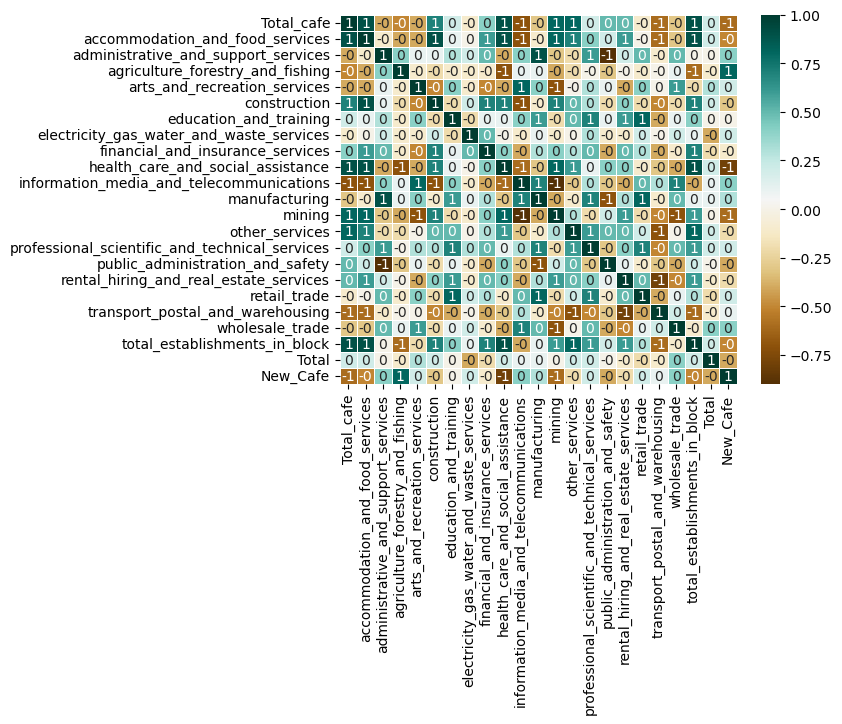

,census_year,administrative_and_support_services,agriculture_forestry_and_fishing,arts_and_recreation_services,education_and_training,electricity_gas_water_and_waste_services,information_media_and_telecommunications,manufacturing,professional_scientific_and_technical_services,retail_trade,transport_postal_and_warehousing,wholesale_trade,New_Cafe
2,2002,22.0,0.0,42.0,12.0,8.0,10.0,8.0,70.0,16.0,6.0,7.0,5
22,2004,20.0,1.0,41.0,13.0,7.0,8.0,6.0,73.0,16.0,3.0,6.0,16
31,2005,13.0,0.0,46.0,15.0,7.0,10.0,6.0,79.0,18.0,3.0,7.0,0
40,2006,13.0,0.0,46.0,15.0,7.0,10.0,6.0,79.0,18.0,3.0,7.0,9
58,2008,12.0,0.0,42.0,17.0,8.0,9.0,6.0,84.0,19.0,4.0,6.0,5


In [216]:
East_Melbourne =heat_map(data,'East Melbourne')
East_Melbourne.head(5)

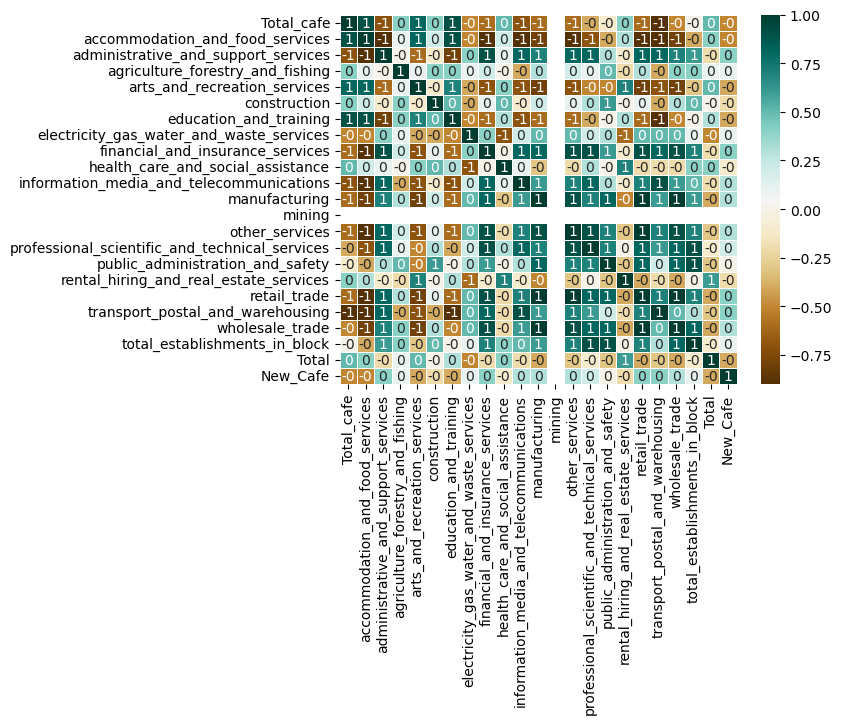

,census_year,administrative_and_support_services,agriculture_forestry_and_fishing,electricity_gas_water_and_waste_services,financial_and_insurance_services,information_media_and_telecommunications,manufacturing,other_services,professional_scientific_and_technical_services,public_administration_and_safety,retail_trade,transport_postal_and_warehousing,wholesale_trade,total_establishments_in_block,New_Cafe
0,2002,40.0,0.0,13.0,41.0,30.0,31.0,146.0,143.0,13.0,166.0,10.0,24.0,1069.0,33
11,2003,38.0,0.0,15.0,44.0,29.0,30.0,166.0,158.0,17.0,168.0,11.0,28.0,1140.0,0
20,2004,38.0,0.0,15.0,44.0,29.0,30.0,166.0,158.0,17.0,168.0,11.0,28.0,1140.0,26
29,2005,36.0,0.0,16.0,43.0,25.0,32.0,153.0,158.0,18.0,166.0,10.0,27.0,1138.0,0
38,2006,36.0,0.0,16.0,43.0,25.0,32.0,153.0,158.0,18.0,166.0,10.0,27.0,1138.0,16


In [215]:
Carlton =heat_map(data,'Carlton')
Carlton.head(5)

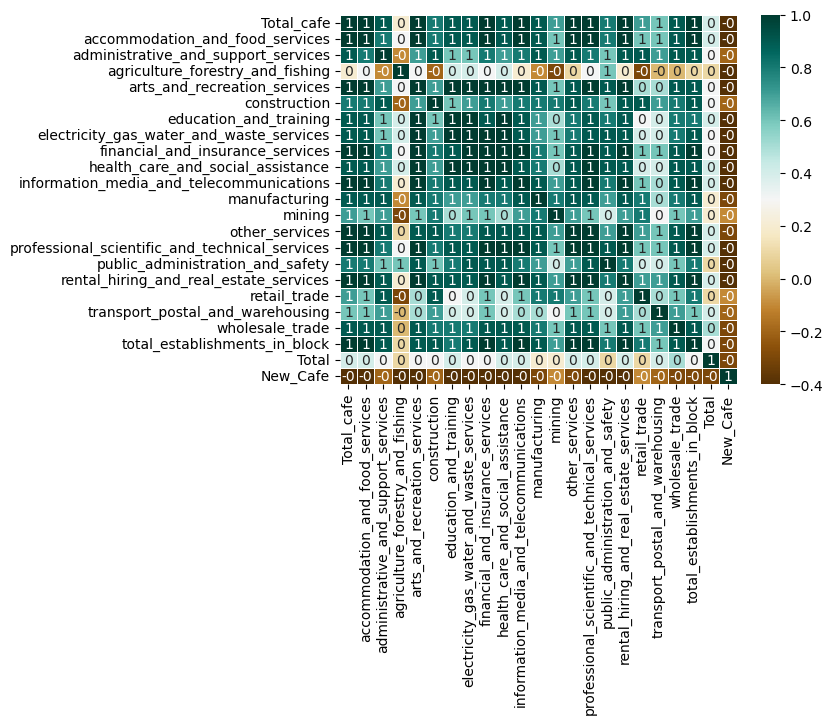

,census_year,New_Cafe
1,2002,26
12,2003,0
21,2004,58
30,2005,0
39,2006,31


In [217]:
Docklands =heat_map(data,'Docklands')
Docklands.head(5)

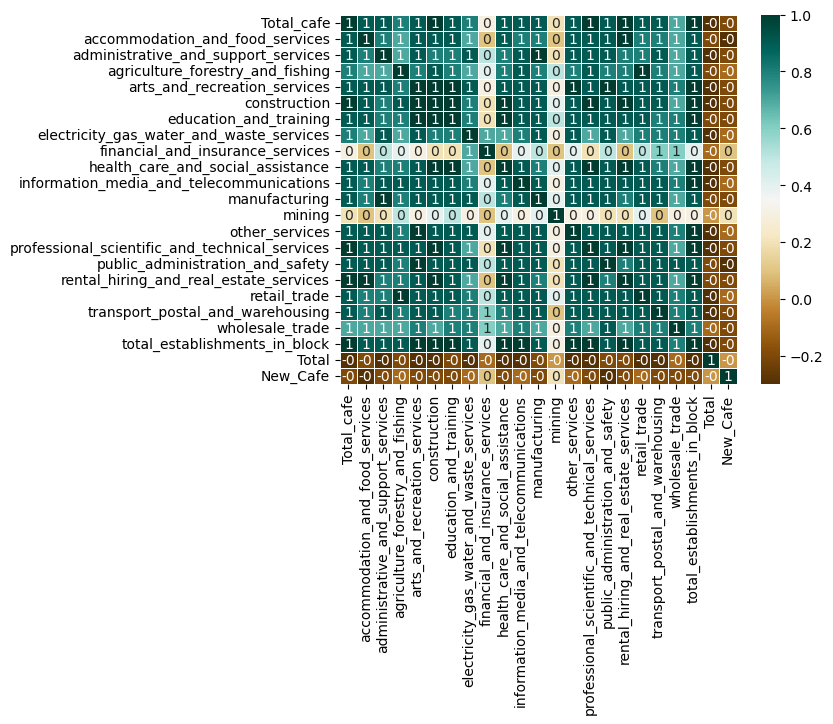

,census_year,financial_and_insurance_services,mining,Total,New_Cafe
3,2002,2.0,0.0,81.0,0
13,2003,2.0,0.0,1332.0,3
23,2004,2.0,0.0,111.0,0
32,2005,2.0,0.0,141.0,1
41,2006,2.0,0.0,88.0,0


In [220]:
Kensington=heat_map(data,'Kensington')
Kensington.head(5)

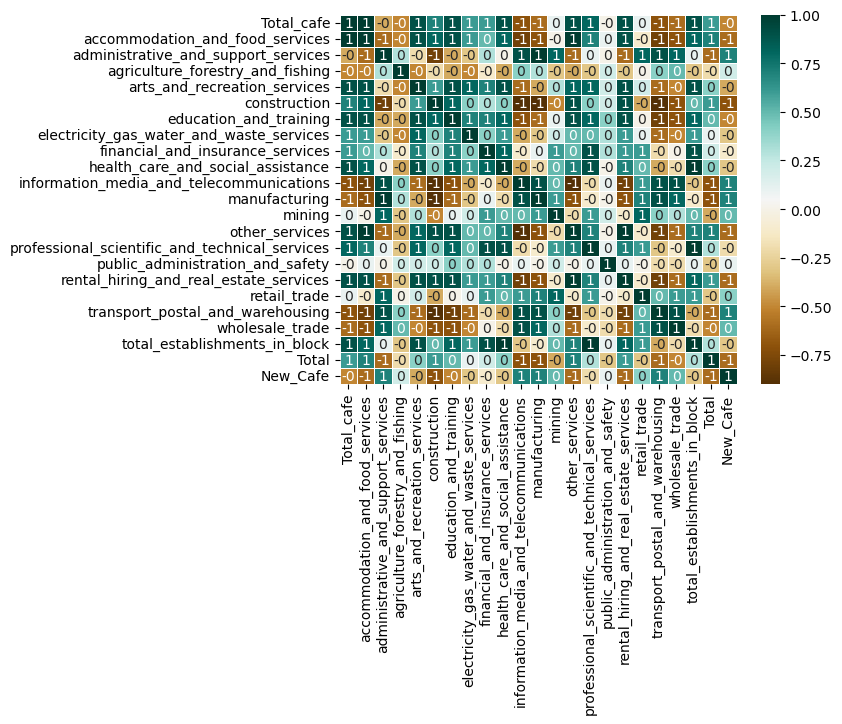

,census_year,administrative_and_support_services,agriculture_forestry_and_fishing,information_media_and_telecommunications,manufacturing,mining,public_administration_and_safety,retail_trade,transport_postal_and_warehousing,wholesale_trade,New_Cafe
4,2002,489.0,7.0,216.0,289.0,31.0,161.0,1317.0,129.0,128.0,0
14,2003,489.0,7.0,216.0,289.0,31.0,161.0,1317.0,129.0,128.0,150
24,2004,510.0,9.0,213.0,287.0,27.0,165.0,1409.0,120.0,132.0,76
33,2005,495.0,9.0,220.0,272.0,36.0,169.0,1557.0,120.0,138.0,75
42,2006,516.0,7.0,227.0,267.0,41.0,170.0,1590.0,117.0,136.0,30


In [224]:
Melbourne = heat_map(data,'Melbourne (CBD)')
Melbourne.head(5)

In [245]:
def model_call(df):
    warnings.filterwarnings("ignore")
    feature = df.loc[(df['census_year']<2018),:].drop(columns=['New_Cafe'])
    target = df.loc[(df['census_year']< 2018),['census_year','New_Cafe']]
    # Encoding the Clue Small Area
    le = LabelEncoder()
    # Standdardising the features
    scaler = StandardScaler()
    #feature.iloc[:,:-1] = scaler.fit_transform(feature.iloc[:,:-1])
    #print(feature.describe)
    
    X_train = feature.loc[(feature['census_year']<2012),:].values
    y_train = target.loc[(target['census_year']<2012),['New_Cafe']].values

    X_test = feature.loc[(feature['census_year']>2011),:].values
    y_test = target.loc[(target['census_year']>2011),['New_Cafe']].values

    X_train = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    y_train = y_train.reshape((y_train.shape[0], 1, y_train.shape[1]))

    #print(feature.head(10))
    #print(target.shape)
    #print(X_train.shape)
    #print(y_train.shape)
    model = Sequential()
    
    model.add(LSTM(500, activation='linear', return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(units=200, activation='linear', return_sequences=True))
    model.add(LSTM(units=50, activation='linear', return_sequences=True))
   #model.add(LSTM(units=20, activation='relu', return_sequences=True))
    #model.add(Dense(100,activation = 'relu'))
    model.add(Dense(units=1,activation='linear'))

    
    model.compile(optimizer='adam', loss='mse')

    model.fit(X_train, y_train, epochs=50, batch_size=2, validation_data=(X_test, y_test), verbose=2)

    loss = model.evaluate(X_test, y_test, verbose=0)
    print('Test Loss:', loss)

    # Make predictions
    predictions = model.predict(X_test)



    # Print predictions
    print('Predictions:', predictions)
    print('Acutal: ', y_test)

In [246]:
model_call(Melbourne)

Epoch 1/50
5/5 - 3s - loss: 3405.6418 - val_loss: 2441.0979 - 3s/epoch - 538ms/step
Epoch 2/50
5/5 - 0s - loss: 2003.2797 - val_loss: 1586.8304 - 72ms/epoch - 14ms/step
Epoch 3/50
5/5 - 0s - loss: 1939.1088 - val_loss: 972.5856 - 63ms/epoch - 13ms/step
Epoch 4/50
5/5 - 0s - loss: 1632.7246 - val_loss: 2141.0876 - 61ms/epoch - 12ms/step
Epoch 5/50
5/5 - 0s - loss: 1553.5868 - val_loss: 2156.2393 - 63ms/epoch - 13ms/step
Epoch 6/50
5/5 - 0s - loss: 1691.4395 - val_loss: 2362.3752 - 66ms/epoch - 13ms/step
Epoch 7/50
5/5 - 0s - loss: 1587.0184 - val_loss: 1254.8755 - 58ms/epoch - 12ms/step
Epoch 8/50
5/5 - 0s - loss: 1632.4412 - val_loss: 1511.3185 - 65ms/epoch - 13ms/step
Epoch 9/50
5/5 - 0s - loss: 1493.9427 - val_loss: 1924.2203 - 58ms/epoch - 12ms/step
Epoch 10/50
5/5 - 0s - loss: 1547.1848 - val_loss: 2588.3572 - 63ms/epoch - 13ms/step
Epoch 11/50
5/5 - 0s - loss: 1635.3958 - val_loss: 1747.0267 - 66ms/epoch - 13ms/step
Epoch 12/50
5/5 - 0s - loss: 1649.4467 - val_loss: 1319.7572 - 64

In [230]:
model_call(Carlton)

Epoch 1/50
5/5 - 4s - loss: 210.6502 - val_loss: 188.9705 - 4s/epoch - 773ms/step
Epoch 2/50
5/5 - 0s - loss: 163.6399 - val_loss: 190.9037 - 70ms/epoch - 14ms/step
Epoch 3/50
5/5 - 0s - loss: 154.7093 - val_loss: 189.0398 - 66ms/epoch - 13ms/step
Epoch 4/50
5/5 - 0s - loss: 158.8169 - val_loss: 192.0718 - 70ms/epoch - 14ms/step
Epoch 5/50
5/5 - 0s - loss: 152.3658 - val_loss: 187.0914 - 67ms/epoch - 13ms/step
Epoch 6/50
5/5 - 0s - loss: 158.5802 - val_loss: 186.0394 - 72ms/epoch - 14ms/step
Epoch 7/50
5/5 - 0s - loss: 156.2747 - val_loss: 190.9622 - 66ms/epoch - 13ms/step
Epoch 8/50
5/5 - 0s - loss: 154.2565 - val_loss: 188.9051 - 66ms/epoch - 13ms/step
Epoch 9/50
5/5 - 0s - loss: 148.1715 - val_loss: 189.3998 - 65ms/epoch - 13ms/step
Epoch 10/50
5/5 - 0s - loss: 149.7214 - val_loss: 186.8369 - 67ms/epoch - 13ms/step
Epoch 11/50
5/5 - 0s - loss: 150.6798 - val_loss: 187.1771 - 68ms/epoch - 14ms/step
Epoch 12/50
5/5 - 0s - loss: 154.0499 - val_loss: 197.5594 - 71ms/epoch - 14ms/step
Ep

In [276]:
def suburb_data(df):
    X_train = df.loc[(df['census_year']<2013),:].drop(columns=['census_year','New_Cafe'])
    y_train = df.loc[(df['census_year']<2013),['New_Cafe']].values

    X_test= df.loc[(df['census_year']>2012)&(df['census_year']<2019),:].drop(columns=['census_year','New_Cafe'])
    y_test = df.loc[(df['census_year']>2012)&(df['census_year']<2019),['New_Cafe']].values

    pred = df.loc[(df['census_year']==2019),:].drop(columns=['census_year','New_Cafe'])

    name = 'Melbourne'
    return X_train, y_train,X_test,y_test,pred,name

In [282]:
def model_svr(parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = SVR(kernel =parameter)
    model.fit(X_train, y_train)
    print(X_train.shape)
    print(X_test.shape)
    print(y_train.shape)
    print(y_test.shape)
    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    
    value = model.predict(pred)
    if value <= 0:
        value = 0
    else:
        value = value.astype(int)
    print(f'The predicted number of new cafe in {name} is {value}')
    plt.scatter(range(len(y_test)), y_test, color ='blue', label='Actual')
    plt.scatter(range(len(y_pred)), y_pred, color= 'red', label ='Predicted')
    plt.xticks(range(len(y_test)),[2013,2014,2015,2016,2017,2018])
    plt.legend()
    plt.show()

In [284]:
def model_GB(parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = GradientBoostingRegressor(n_estimators=parameter, learning_rate=0.08, max_depth=10, random_state=2)
    model.fit(X_train, y_train)
    print(X_train.shape)
    print(X_test.shape)
    print(y_train.shape)
    print(y_test.shape)
    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    
    value_2022 = model.predict(pred)
    if value_2022 < 0:
        value_2022 = 0
    else:
        value_2022 = value_2022.astype(int)
    print(f'The predicted number of new cafe in {name} is {value_2022}')
    plt.scatter(range(len(y_test)), y_test, color ='blue', label='Actual')
    plt.scatter(range(len(y_pred)), y_pred, color= 'red', label ='Predicted')
    plt.xticks(range(len(y_test)),[2013,2014,2015,2016,2017,2018])
    plt.legend()
    plt.show()

In [285]:
def model_LR(parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = LinearRegression()
    model.fit(X_train, y_train)
    print(X_train.shape)
    print(X_test.shape)
    print(y_train.shape)
    print(y_test.shape)
    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    
    value_2022 = model.predict(pred)
    if value_2022 < 0:
        value_2022 = 0
    else:
        value_2022 = value_2022.astype(int)
    print(f'The predicted number of new cafe in {name} is {value_2022}')
    plt.scatter(range(len(y_test)), y_test, color ='blue', label='Actual')
    plt.scatter(range(len(y_pred)), y_pred, color= 'red', label ='Predicted')
    plt.xticks(range(len(y_test)),[2013,2014,2015,2016,2017,2018])
    plt.legend()
    plt.show()

In [286]:
def model_DT(parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = DecisionTreeRegressor(max_depth = parameter)
    model.fit(X_train, y_train)
    print(X_train.shape)
    print(X_test.shape)
    print(y_train.shape)
    print(y_test.shape)
    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    
    value_2022 = model.predict(pred)
    if value_2022 < 0:
        value_2022 = 0
    else:
        value_2022 = value_2022.astype(int)
    print(f'The predicted number of new cafe in {name} is {value_2022}')
    plt.scatter(range(len(y_test)), y_test, color ='blue', label='Actual')
    plt.scatter(range(len(y_pred)), y_pred, color= 'red', label ='Predicted')
    plt.xticks(range(len(y_test)),[2013,2014,2015,2016,2017,2018])
    plt.legend()
    plt.show()

(11, 9)
(6, 9)
(11, 1)
(6, 1)
Mean Suqared Error: 240.67586615624842
R-squared 0.42452635616199896
The predicted number of new cafe in Melbourne is [15]


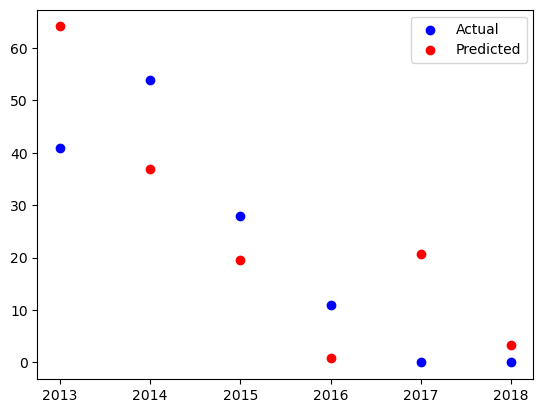

In [304]:
CX_train, CY_train, CX_test, CY_test, Cpred ,Cname= suburb_data(Melbourne)
model_svr('linear',CX_train, CX_test,CY_train, CY_test, Cpred, Cname)

(11, 9)
(6, 9)
(11, 1)
(6, 1)
Mean Suqared Error: 2252.4550347947857
R-squared -4.3857851522723355
The predicted number of new cafe in Melbourne is [66]


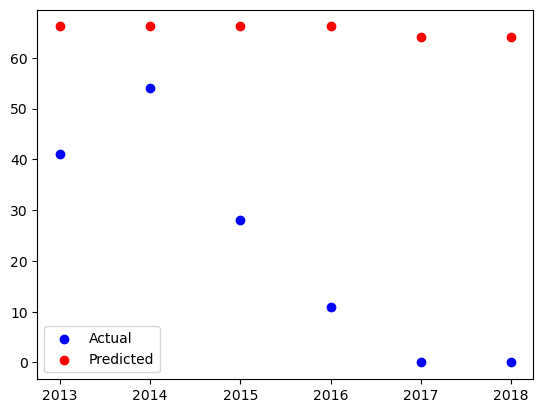

In [288]:
model_GB(3,CX_train, CX_test,CY_train, CY_test, Cpred, Cname)

(11, 9)
(6, 9)
(11, 1)
(6, 1)
Mean Suqared Error: 1584.8297070620993
R-squared -2.789444039202681
The predicted number of new cafe in Melbourne is [[68]]


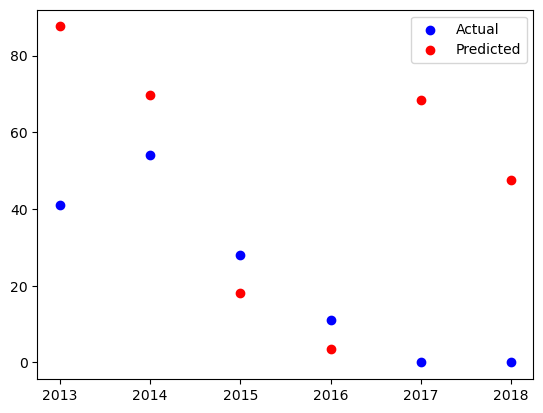

In [289]:
model_LR(3,CX_train, CX_test,CY_train, CY_test, Cpred, Cname)

(11, 9)
(6, 9)
(11, 1)
(6, 1)
Mean Suqared Error: 477.0
R-squared -0.1405419766206164
The predicted number of new cafe in Melbourne is [30]


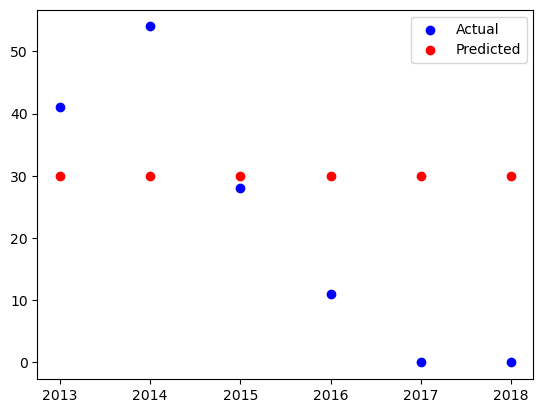

In [290]:
model_DT(30,CX_train, CX_test,CY_train, CY_test, Cpred, Cname)

In [328]:
## Attempting model tunning
# defining parameter range 
param_grid = {'C': np.logspace(-3, 3, 3),
              'gamma': np.logspace(-4, 0, 5),
              'kernel': ['rbf', 'linear']}

# Initialize GridSearchCV
warnings.filterwarnings("ignore")
grid = GridSearchCV(SVR(), param_grid, cv=5, verbose=3, scoring='neg_mean_absolute_percentage_error', n_jobs=1)
warnings.filterwarnings("ignore")
# Fit the model for grid search
with warnings.catch_warnings():
    warnings.filterwarnings("ignore")
    grid.fit(CX_train, CY_train)
    warnings.filterwarnings("ignore")

# Print the best hyperparameters found
warnings.filterwarnings("ignore")
print("Best Parameters:", grid.best_params_)
warnings.filterwarnings("ignore")
print('Best score:', grid.best_score_)
warnings.filterwarnings("ignore")
print('Best scorer:', grid.scorer_)
warnings.filterwarnings("ignore")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
[CV 1/5] END C=0.001, gamma=0.0001, kernel=rbf;, score=-114091285869076432.000 total time=   0.0s
[CV 2/5] END C=0.001, gamma=0.0001, kernel=rbf;, score=-0.797 total time=   0.0s
[CV 3/5] END C=0.001, gamma=0.0001, kernel=rbf;, score=-0.056 total time=   0.0s
[CV 4/5] END C=0.001, gamma=0.0001, kernel=rbf;, score=-0.145 total time=   0.0s
[CV 5/5] END C=0.001, gamma=0.0001, kernel=rbf;, score=-0.642 total time=   0.0s
[CV 1/5] END C=0.001, gamma=0.0001, kernel=linear;, score=-117476936204805808.000 total time=   0.0s
[CV 2/5] END C=0.001, gamma=0.0001, kernel=linear;, score=-0.793 total time=   0.0s
[CV 3/5] END C=0.001, gamma=0.0001, kernel=linear;, score=-0.070 total time=   0.0s
[CV 4/5] END C=0.001, gamma=0.0001, kernel=linear;, score=-0.141 total time=   0.0s
[CV 5/5] END C=0.001, gamma=0.0001, kernel=linear;, score=-0.696 total time=   0.0s
[CV 1/5] END C=0.001, gamma=0.001, kernel=rbf;, score=-114091135335396016.000 t

In [256]:
def model_svr_best(c,gamma,parameter, X_train, X_test, y_train, y_test, pred, name):
    warnings.filterwarnings("ignore")
    model = SVR(C=c, gamma= gamma,kernel =parameter)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse =mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test,y_pred)
    print('Mean Suqared Error:',mse)
    print('R-squared',r2)
    
    value_2022 = model.predict(pred)
    if value_2022 < 0:
        value_2022 = 0
    else:
        value_2022 = value_2022.astype(int)
    print(f'The predicted number of new cafe in {name} is {value_2022}')
    plt.scatter(range(len(y_test)), y_test, color ='blue', label='Actual')
    plt.scatter(range(len(y_pred)), y_pred, color= 'red', label ='Predicted')
    plt.legend()
    plt.show()

Mean Suqared Error: 2144.9649696014994
R-squared -4.128768524551938
The predicted number of new cafe in Melbourne is [63]


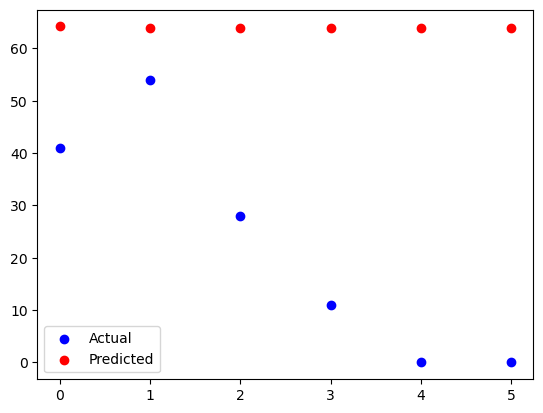

In [329]:
model_svr_best(1000,0.001,'rbf',CX_train, CX_test,CY_train, CY_test, Cpred, Cname)